In [5]:
from google.colab import files

print("Please upload the 'chat_data.csv' file.")
uploaded = files.upload()

Please upload the 'chat_data.csv' file.


Saving archive (2) (1).zip to archive (2) (1) (1).zip


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


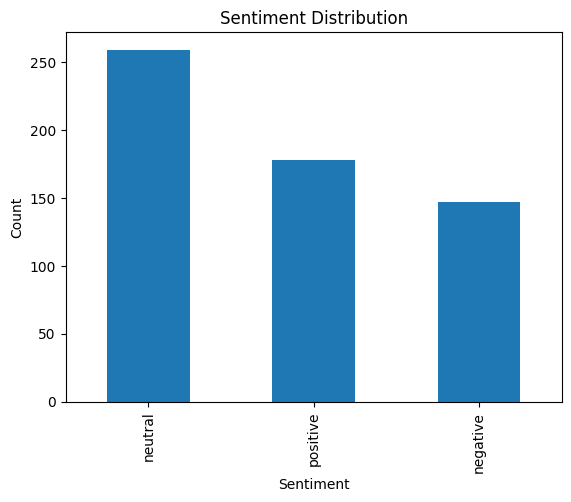

<Figure size 640x480 with 0 Axes>

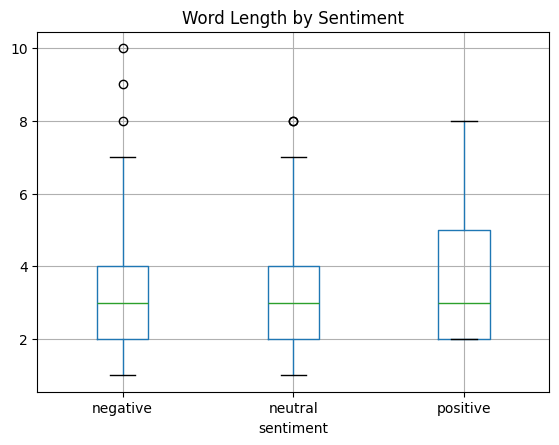

Top 20 words: [('im', 213), ('feeling', 61), ('sure', 34), ('average', 31), ('today', 28), ('service', 26), ('bit', 25), ('product', 24), ('hotel', 24), ('dont', 23), ('got', 21), ('food', 20), ('time', 19), ('new', 19), ('movie', 18), ('love', 18), ('work', 17), ('trying', 16), ('standard', 15), ('thing', 15)]

--- Logistic Regression (BoW) ---
Accuracy: 0.8205128205128205
              precision    recall  f1-score   support

           0       0.78      0.62      0.69        29
           1       0.82      0.94      0.88        52
           2       0.85      0.81      0.83        36

    accuracy                           0.82       117
   macro avg       0.82      0.79      0.80       117
weighted avg       0.82      0.82      0.82       117

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 129ms/step - accuracy: 0.4263 - loss: 1.0838 - val_accuracy: 0.4574 - val_loss: 1.0684
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - accuracy: 0.4397 - loss: 1.0814 - val_accuracy: 0.4574 - val_loss: 1.0791
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 152ms/step - accuracy: 0.4397 - loss: 1.0744 - val_accuracy: 0.4574 - val_loss: 1.0604
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step - accuracy: 0.4397 - loss: 1.0756 - val_accuracy: 0.4574 - val_loss: 1.0555
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - accuracy: 0.4397 - loss: 1.0733 - val_accuracy: 0.4574 - val_loss: 1.0646
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - accuracy: 0.4424 - loss: 1.0811 - val_accuracy: 0.4574 - val_loss: 1.0609
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.4397 - loss: 1.0842 - val_accuracy: 0.4574 - val_loss: 1.0695
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.4397 - loss: 1.0809 - val_accuracy: 0.4574 - val_loss:

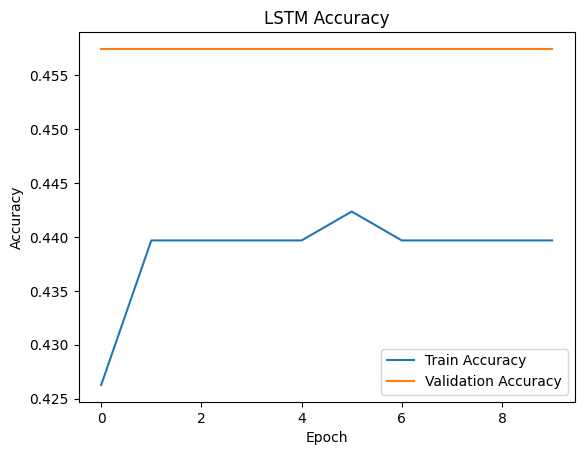

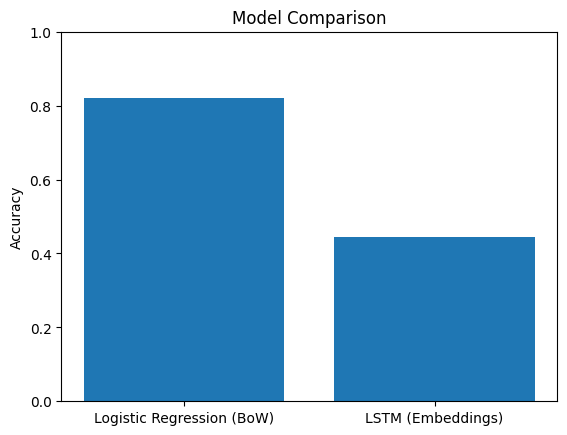

In [6]:
import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt
from collections import Counter
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Embedding, LSTM
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
import zipfile
import io


# 1. Download NLTK resources

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')


# 2. Load dataset

# Assuming 'uploaded' variable is available from previous file upload
# and contains the zip file content.
# Get the name of the uploaded zip file (e.g., 'archive (2) (1).zip')
zip_file_name = list(uploaded.keys())[0]
zip_content = uploaded[zip_file_name]

# Unzip the content
with zipfile.ZipFile(io.BytesIO(zip_content), 'r') as zip_ref:
    zip_ref.extractall()

# Now, read the extracted CSV file. Based on the uploaded content, it's 'chat_dataset.csv'.
df = pd.read_csv("chat_dataset.csv")
df = df.dropna(subset=["message", "sentiment"])

# 3. Text preprocessing

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return " ".join(tokens)

df["clean_message"] = df["message"].apply(preprocess_text)

# 4. Exploratory Data Analysis

sentiment_counts = df["sentiment"].value_counts()
plt.figure()
sentiment_counts.plot(kind="bar")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

df["word_length"] = df["clean_message"].apply(lambda x: len(x.split()))
plt.figure()
df.boxplot(column="word_length", by="sentiment")
plt.title("Word Length by Sentiment")
plt.suptitle("")
plt.show()

all_words = []
for msg in df["clean_message"]:
    all_words.extend(msg.split())
word_freq = Counter(all_words)
print("Top 20 words:", word_freq.most_common(20))

# 5. Encode labels

le = LabelEncoder()
y = le.fit_transform(df["sentiment"])
y_cat = to_categorical(y)

# 6. Train/Test split

X_text = df["clean_message"]
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y_cat, test_size=0.2, random_state=42, stratify=y
)

# MODEL 1: Logistic Regression (Bag of Words)

vectorizer = CountVectorizer(max_features=1000)
X_train_bow = vectorizer.fit_transform(X_train_text)
X_test_bow = vectorizer.transform(X_test_text)

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_bow, y_train.argmax(axis=1))
y_pred_lr = lr_model.predict(X_test_bow)

print("\n--- Logistic Regression (BoW) ---")
print("Accuracy:", accuracy_score(y_test.argmax(axis=1), y_pred_lr))
print(classification_report(y_test.argmax(axis=1), y_pred_lr))


# MODEL 2: LSTM with Word Embeddings

max_words = 5000
max_len = 50

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

embedding_dim = 100

lstm_model = Sequential()
lstm_model.add(Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_len))
lstm_model.add(LSTM(128))
lstm_model.add(Dropout(0.5))
lstm_model.add(Dense(y_train.shape[1], activation='softmax'))

lstm_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
history = lstm_model.fit(X_train_pad, y_train, validation_split=0.2, epochs=10, batch_size=32)

loss, acc_lstm = lstm_model.evaluate(X_test_pad, y_test)
print("\n--- LSTM with Embeddings ---")
print("Test Accuracy:", acc_lstm)


# Plot LSTM Training

plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("LSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Final Comparison

models = ['Logistic Regression (BoW)', 'LSTM (Embeddings)']
accuracies = [
    accuracy_score(y_test.argmax(axis=1), y_pred_lr),
    acc_lstm
]

plt.figure()
plt.bar(models, accuracies)
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.ylim(0,1)
plt.show()
